In [ ]:
from src.python.models import unet  # Add more models as needed
from src.python.data.dataloader import get_dataloaders, BASIC_TRANSFORM, ROW_SPLIT_TRANSFORM, RowAverageSplitInverseTransform
from src.python.config import get_config
import torch
import os
import time
import numpy as np
import matplotlib.pyplot as plt
from src.python.postprocess import postprocess,radial_wrap
from src.python.models import get_model
import mlflow
import tqdm
from skimage.io import imshow

In [2]:
config = get_config("configs/unet-2chan.json")

In [3]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = get_model(config).to(device)
# Load weights
weights_path = config.get('evaluation.model_path', './best_model.pth')
path_from_mlflow = config.get('evaluation.path_from_mlflow', False)
if path_from_mlflow:
    print(f"Loading model weights from MLflow artifact: {weights_path}")
    local_path = mlflow.artifacts.download_artifacts(artifact_uri=weights_path)
    model.load_state_dict(torch.load(local_path, map_location=device))
    print(f"Loaded weights from MLflow artifact at {weights_path}")
elif os.path.exists(weights_path):
    model.load_state_dict(torch.load(weights_path, map_location=device))
    print(f"Loaded weights from {weights_path}")
else:
    print(f"Weights not found at {weights_path}, using random init.")

model.eval()
preds = []
targets = []
total_pred_time = 0.0
num_batches = 0
two_channel_split = config.get('data.split_channels', False)

Loaded weights from /home/acap/faks/pl-terrain-prediction/output/unet-2chan/unet-2chan.pth


In [4]:
transform = ROW_SPLIT_TRANSFORM if two_channel_split else BASIC_TRANSFORM
_, test_loader = get_dataloaders(config, transform=transform, val_split=0.01)

In [5]:
with torch.no_grad():
    for inputs, targs in tqdm.tqdm(test_loader, total=len(test_loader)):
        inputs = inputs.to(device)
        targs = targs.to(device)
        start_time = time.perf_counter()
        outputs = model(inputs)
        end_time = time.perf_counter()
        batch_time = end_time - start_time
        total_pred_time += batch_time
        num_batches += 1
        preds.append(outputs.cpu())
        targets.append(targs.cpu())
preds = torch.cat(preds, dim=0)
targets = torch.cat(targets, dim=0)
# Compute MSE
mse = torch.nn.functional.mse_loss(preds, targets).item()
print(f"Test MSE: {mse:.6f}")

avg_pred_time = total_pred_time / num_batches if num_batches > 0 else 0.0
print(f"Total prediction time: {total_pred_time:.4f} s")
print(f"Average prediction time per batch: {avg_pred_time:.6f} s")

100%|██████████| 9/9 [00:03<00:00,  2.63it/s]

Test MSE: 0.005310
Total prediction time: 0.5704 s
Average prediction time per batch: 0.063379 s


In [8]:
merged_targs= targets[:, 0, :, :] + targets[:, 1, :, :]

In [ ]:
merged_preds= preds[:, 0, :, :] + preds[:, 1, :, :]

In [51]:
merged_preds = (merged_preds - merged_preds.min()) / (merged_preds.max() - merged_preds.min())

/tmp/ipykernel_13579/757790083.py:3: FutureWarning: `imshow` is deprecated since version 0.25 and will be removed in version 0.27. Please use `matplotlib`, `napari`, etc. to visualize images.
  imshow(merged_preds[0].cpu().numpy())


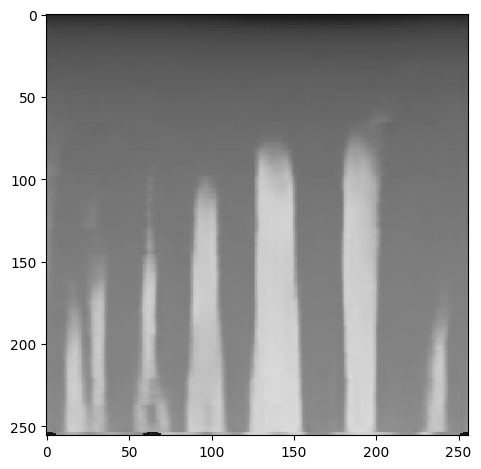

In [52]:
# preds = preds[:, 0, :, :].unsqueeze(1)
# targets = targets[:, 0, :, :].unsqueeze(1)
imshow(merged_preds[0].cpu().numpy())


In [ ]:
from skimage.transform import resize
from 

In [ ]:
unwrap_img = np.squeeze(merged_preds[0, :, :])
center = (unwrap_img.shape[0] / 2, unwrap_img.shape[1] / 2)
wrp_img = radial_wrap(unwrap_img, (256, 256), center)

wrp_img = wrp_img * 255 if is_tensor else wrp_img
imshow(wrp_img, cmap='gray')
# wrp_img = wrp_img.astype(np.uint8)
output_image_name = os.path.join(out_dir, f"{base_name}_wrap{i+1:03d}.png")

img_res = resize(
    wrp_img, (256, 256), order=1, preserve_range=True
).astype(np.uint8)

Wrapping images: 100%|██████████| 143/143 [00:02<00:00, 51.54it/s]


[]